# v4-data — Data section notebook

This notebook builds **data explanatory tables and graphs** for the thesis.

It prioritises the main-text package and also generates appendix diagnostics.

**Inputs (automatic):**
- `Data/Clean/Final-v4.csv`
- `v4-simulation.xlsx` (if available; used for simulation-specific baseline objects)

**Outputs:**
- Tables displayed in-notebook
- Figures saved in `imgs/` with `data_` prefix

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from ast import literal_eval

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

ROOT = Path('.')
CSV_PATH = ROOT / 'Data/Clean/Final-v4.csv'
XLSX_PATH = ROOT / 'v4-simulation.xlsx'
OUT_DIR = ROOT / 'imgs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert CSV_PATH.exists(), f'Missing file: {CSV_PATH}'

df_raw = pd.read_csv(CSV_PATH)
xls = pd.ExcelFile(XLSX_PATH) if XLSX_PATH.exists() else None

def read_sheet(name):
    if xls is not None and name in xls.sheet_names:
        return pd.read_excel(XLSX_PATH, sheet_name=name)
    return None

config = read_sheet('Config')
macro = read_sheet('Macro_Variables')
portfolio_data_sheet = read_sheet('Portfolio_Data')

def parse_csv_list(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s.startswith('[') and s.endswith(']'):
        try:
            return [str(v).strip().strip("'").strip('"') for v in literal_eval(s)]
        except Exception:
            pass
    return [p.strip() for p in s.split(',') if p.strip()]

if config is not None:
    cfg = dict(zip(config['parameter'], config['value']))
    EU27 = parse_csv_list(cfg.get('EU27', ''))
    OUTSIDE = parse_csv_list(cfg.get('OUTSIDE', ''))
    FINANCIAL_CENTRES = set(parse_csv_list(cfg.get('FINANCIAL_CENTRES', 'IRL, LUX, CYP, MLT')))
    base_year_cfg = int(cfg.get('BASE_YEAR', 2019))
else:
    EU27 = ['AUT','BEL','BGR','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC','HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK','SVN','ESP','SWE']
    OUTSIDE = ['GBR','CHE','NOR']
    FINANCIAL_CENTRES = {'IRL', 'LUX', 'CYP', 'MLT'}
    base_year_cfg = 2019

if macro is not None and 'country' in macro.columns:
    SIM_COUNTRIES = macro['country'].dropna().astype(str).tolist()
else:
    SIM_COUNTRIES = sorted(set(df_raw['iso3_i']).intersection(set(df_raw['iso3_j'])))

raw_years = sorted(df_raw['year'].dropna().astype(int).unique().tolist())
BASE_YEAR = 2019

print(f'Loaded rows: {len(df_raw):,}')
print(f'Countries in simulation set: {len(SIM_COUNTRIES)}')
print(f'Base year used in this notebook: {BASE_YEAR}')
print(f'Excel available: {XLSX_PATH.exists()}')
print(f'Output folder: {OUT_DIR}')

# Filter to simulation country set
df_country = df_raw[df_raw['iso3_i'].isin(SIM_COUNTRIES) & df_raw['iso3_j'].isin(SIM_COUNTRIES)].copy()
print(f'Observations in simulation country set: {len(df_country):,}')


Loaded rows: 1,535,274
Countries in simulation set: 29
Base year used in this notebook: 2019
Excel available: True
Output folder: imgs
Observations in simulation country set: 21,866


In [2]:
# Build filtered samples and helper objects

# Compute d_financial_development_index if not present
if 'd_financial_development_index' not in df_country.columns and 'financial_development_index_i' in df_country.columns:
    df_country['d_financial_development_index'] = np.abs(
        df_country['financial_development_index_i'] - df_country['financial_development_index_j']
    )

ppml_cols = [
    'a_ij', 'd_ling', 'd_num_articles', 'd_geo', 'year', 'iso3_i', 'iso3_j', 'Y_i', 'Y_j'
]
if 'd_financial_development_index' in df_country.columns:
    ppml_cols.append('d_financial_development_index')

df_country['a_ij_raw'] = df_country['a_ij']
neg_before = int((df_country['a_ij_raw'] < 0).sum())
df_country['a_ij'] = df_country['a_ij'].clip(lower=0)
neg_after = int((df_country['a_ij'] < 0).sum())

df_ppml = df_country[df_country['iso3_i'] != df_country['iso3_j']].copy()
raw_ppml_obs = len(df_ppml)
# Only drop if the required columns exist
ppml_cols_exist = [c for c in ppml_cols if c in df_ppml.columns]
df_ppml = df_ppml.dropna(subset=ppml_cols_exist).copy()

base = df_country[df_country['year'] == BASE_YEAR].copy()
base = base[base['iso3_i'].isin(SIM_COUNTRIES) & base['iso3_j'].isin(SIM_COUNTRIES)].copy()

A = base.pivot_table(index='iso3_i', columns='iso3_j', values='a_ij', aggfunc='mean')
A = A.reindex(index=SIM_COUNTRIES, columns=SIM_COUNTRIES)

# Match simulation logic for observed home share:
# a_ii = total_portfolio_million_usd_i - total_pip_million_usd_i (with small floor)
n_diag_imputed = 0
if {'total_portfolio_million_usd_i', 'total_pip_million_usd_i'}.issubset(base.columns):
    country_totals = (
        base.drop_duplicates('iso3_i')
        .set_index('iso3_i')[['total_portfolio_million_usd_i', 'total_pip_million_usd_i']]
    )
    for c in SIM_COUNTRIES:
        if c not in country_totals.index:
            continue
        tot_port = country_totals.at[c, 'total_portfolio_million_usd_i']
        tot_pip = country_totals.at[c, 'total_pip_million_usd_i']
        if pd.isna(tot_port) or pd.isna(tot_pip) or tot_port <= 0:
            continue
        home_val = tot_port - tot_pip
        if home_val < 0.01 * tot_port:
            home_val = 0.01 * tot_port
        A.loc[c, c] = home_val
        n_diag_imputed += 1

s_total = A.sum(axis=1)
Pi_data = A.div(s_total.replace(0, np.nan), axis=0)
home_share = pd.Series(np.diag(Pi_data), index=SIM_COUNTRIES, name='observed_home_share')

domestic_holdings = pd.Series(np.diag(A), index=SIM_COUNTRIES, name='observed_domestic_holdings')
foreign_holdings = (s_total - domestic_holdings).rename('foreign_portfolio_holdings')

if macro is not None and {'country','pi_home_data'}.issubset(macro.columns):
    home_share = macro.set_index('country')['pi_home_data'].reindex(SIM_COUNTRIES)
    home_share.name = 'observed_home_share'

print(f'Country-filtered observations: {len(df_country):,}')
print(f'PPML observations after i!=j and NA filtering: {len(df_ppml):,}')
print(f'Base-year simulation observations: {len(base):,}')
print(f'Negative holdings before flooring: {neg_before:,} | after flooring: {neg_after:,}')
print(f'PPML columns available: {ppml_cols_exist}')
print(f'Diagonal home holdings imputed from totals: {n_diag_imputed}')


Country-filtered observations: 21,866
PPML observations after i!=j and NA filtering: 2,858
Base-year simulation observations: 841
Negative holdings before flooring: 8 | after flooring: 0
PPML columns available: ['a_ij', 'd_ling', 'd_num_articles', 'd_geo', 'year', 'iso3_i', 'iso3_j', 'Y_i', 'Y_j', 'd_financial_development_index']
Diagonal home holdings imputed from totals: 29


## Main-text package tables

In [3]:
# 1) Data sources table (main text)
main_data_sources_rows = [
    {
        'dataset name': 'IMF bilateral portfolio holdings (CPIS/PIP)',
        'raw file/source': 'Data/Clean/Final-v4.csv (built from IMF CPIS/PIP bilateral inputs)',
        'variables taken': 'a_ij',
        'unit': 'USD million',
        'frequency': 'Annual',
        'years': f"{int(df_raw['year'].min())}-{int(df_raw['year'].max())}",
        'role in the model': 'Core dependent variable in gravity; bilateral allocation target in simulation'
    },
    {
        'dataset name': 'IMF total foreign portfolio holdings',
        'raw file/source': 'Data/Clean/Final-v4.csv (IMF PIP totals merged)',
        'variables taken': 'total_pip_million_usd_i (and j-side where available)',
        'unit': 'USD million',
        'frequency': 'Annual',
        'years': f"{int(df_raw['year'].min())}-{int(df_raw['year'].max())}",
        'role in the model': 'Used with total portfolio wealth to reconstruct domestic holdings a_ii'
    },
    {
        'dataset name': 'Eurostat total portfolio wealth',
        'raw file/source': 'Data/Clean/Final-v4.csv (Eurostat totals merged)',
        'variables taken': 'total_portfolio_million_usd_i (and j-side where available)',
        'unit': 'USD million',
        'frequency': 'Annual',
        'years': f"{int(df_raw['year'].min())}-{int(df_raw['year'].max())}",
        'role in the model': 'Country wealth totals used for a_ii and observed home share π_ii'
    },
    {
        'dataset name': 'Penn World Tables (PWT)',
        'raw file/source': 'Data/Clean/Final-v4.csv (PWT merged variables)',
        'variables taken': 'Y_i, Y_j, k_i, L_i, A_i, alpha_i',
        'unit': 'USD million / persons / index / share',
        'frequency': 'Annual',
        'years': f"{int(df_raw['year'].min())}-{int(df_raw['year'].max())}",
        'role in the model': 'Gravity mass terms and simulation fundamentals (returns and production side)'
    },
    {
        'dataset name': 'IMF Financial Development Index',
        'raw file/source': 'Data/Clean/Final-v4.csv (IMF FDI index merged)',
        'variables taken': 'financial_development_index_i, financial_development_index_j, d_financial_development_index',
        'unit': 'Index and bilateral distance (absolute difference)',
        'frequency': 'Annual',
        'years': f"{int(df_raw['year'].min())}-{int(df_raw['year'].max())}",
        'role in the model': 'Wedge/friction variable in gravity and simulation (policy-sensitive)'
    },
    {
        'dataset name': 'CEPII language/geography',
        'raw file/source': 'Data/Clean/Final-v4.csv (CEPII merges)',
        'variables taken': 'd_ling, d_geo',
        'unit': 'Distance metrics',
        'frequency': 'Mostly time-invariant',
        'years': 'Pair-level constants / panel-merged',
        'role in the model': 'Core bilateral frictions in gravity and simulation wedges'
    },
    {
        'dataset name': 'IntenSE / news coverage',
        'raw file/source': 'Data/Clean/Final-v4.csv (IntenSE-derived distance merge)',
        'variables taken': 'd_num_articles',
        'unit': 'Normalized distance',
        'frequency': 'Annual',
        'years': f"{int(df_raw['year'].min())}-{int(df_raw['year'].max())}",
        'role in the model': 'Information wedge/friction in gravity and simulation (policy-sensitive)'
    },
]

data_sources_table = pd.DataFrame(main_data_sources_rows)
display(data_sources_table)

# Detect additional merged datasets that are present but not used in the core model block
extra_dataset_specs = [
    ('MSCI returns', ['msci', 'etf', 'return']),
    ('BIS debt', ['bis', 'debt']),
    ('WEF GCI', ['gci', 'competitiveness']),
    ('Hofstede cultural dimensions', ['hofstede']),
    ('KAOPEN', ['kaopen']),
]
extra_rows = []
cols_lower = {c.lower(): c for c in df_raw.columns}
for label, keywords in extra_dataset_specs:
    matched = [orig for low, orig in cols_lower.items() if any(k in low for k in keywords)]
    if len(matched) == 0:
        continue
    extra_rows.append({
        'dataset name': label,
        'raw file/source': 'Merged into Data/Clean/Final-v4.csv',
        'variables found in Final-v4': ', '.join(sorted(set(matched[:8]))) + (' ...' if len(matched) > 8 else ''),
        'kept in main section?': 'No (not used in current gravity/simulation block)'
    })
supplementary_data_sources_table = pd.DataFrame(extra_rows)
if len(supplementary_data_sources_table) > 0:
    print('Appendix note: Additional merged datasets detected (not used in current model block).')
    display(supplementary_data_sources_table)

# 2) Variable dictionary table (final model variables)
variable_dictionary_rows = [
    {'variable': 'a_ij', 'raw/constructed': 'Raw', 'formula or derivation': 'Observed bilateral holdings from IMF CPIS/PIP merge', 'source': 'IMF bilateral portfolio holdings', 'unit': 'USD million', 'used in gravity': 'Yes', 'used in simulation': 'Yes', 'interpretation': 'Portfolio holdings from investor i to destination j'},
    {'variable': 'a_ii', 'raw/constructed': 'Constructed', 'formula or derivation': 'total_portfolio_million_usd_i - total_pip_million_usd_i; floor at 1% of portfolio', 'source': 'Eurostat + IMF totals', 'unit': 'USD million', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Domestic holdings used to recover home bias'},
    {'variable': 'pi_ij', 'raw/constructed': 'Constructed', 'formula or derivation': 'a_ij / Σ_j a_ij', 'source': 'Constructed from bilateral matrix A', 'unit': 'Share [0,1]', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Observed portfolio share matrix target'},
    {'variable': 'pi_ii', 'raw/constructed': 'Constructed', 'formula or derivation': 'a_ii / Σ_j a_ij (diagonal of π)', 'source': 'Constructed from A and totals', 'unit': 'Share [0,1]', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Observed home share used in diagonal calibration'},
    {'variable': 'Y_i', 'raw/constructed': 'Raw', 'formula or derivation': 'GDP of investor country i', 'source': 'PWT', 'unit': 'USD million', 'used in gravity': 'Yes', 'used in simulation': 'Yes', 'interpretation': 'Economic mass of investor'},
    {'variable': 'Y_j', 'raw/constructed': 'Raw', 'formula or derivation': 'GDP of destination country j', 'source': 'PWT', 'unit': 'USD million', 'used in gravity': 'Yes', 'used in simulation': 'Yes', 'interpretation': 'Economic mass of destination'},
    {'variable': 'k_i', 'raw/constructed': 'Raw', 'formula or derivation': 'Physical capital stock of i', 'source': 'PWT', 'unit': 'USD million', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Capital input in simulation baseline'},
    {'variable': 'L_i', 'raw/constructed': 'Raw', 'formula or derivation': 'Labour input of i', 'source': 'PWT', 'unit': 'Persons/index', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Labour input in production block'},
    {'variable': 'A_i', 'raw/constructed': 'Raw', 'formula or derivation': 'TFP level of i', 'source': 'PWT', 'unit': 'Index', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Productivity shifter'},
    {'variable': 'alpha_i', 'raw/constructed': 'Raw', 'formula or derivation': 'Capital share parameter', 'source': 'PWT', 'unit': 'Share [0,1]', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Output elasticity of capital'},
    {'variable': 'R_j', 'raw/constructed': 'Constructed', 'formula or derivation': '(alpha_j * Y_j / k_j) / mean(alpha * Y / k)', 'source': 'Constructed from PWT variables', 'unit': 'Index (mean=1)', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Normalized return proxy for destination attractiveness'},
    {'variable': 'total_portfolio_million_usd', 'raw/constructed': 'Raw', 'formula or derivation': 'Country total portfolio wealth', 'source': 'Eurostat totals', 'unit': 'USD million', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Total investable wealth by country'},
    {'variable': 'total_pip_million_usd', 'raw/constructed': 'Raw', 'formula or derivation': 'Country total foreign portfolio holdings', 'source': 'IMF PIP totals', 'unit': 'USD million', 'used in gravity': 'No', 'used in simulation': 'Yes', 'interpretation': 'Aggregate foreign holdings used in domestic reconstruction'},
    {'variable': 'd_ling', 'raw/constructed': 'Raw', 'formula or derivation': 'CEPII language-based bilateral distance', 'source': 'CEPII', 'unit': 'Distance index', 'used in gravity': 'Yes', 'used in simulation': 'Yes', 'interpretation': 'Cultural/information friction'},
    {'variable': 'd_geo', 'raw/constructed': 'Raw', 'formula or derivation': 'CEPII geographic bilateral distance', 'source': 'CEPII', 'unit': 'Distance metric', 'used in gravity': 'Yes', 'used in simulation': 'Yes', 'interpretation': 'Physical friction'},
    {'variable': 'd_num_articles', 'raw/constructed': 'Raw', 'formula or derivation': 'News/information distance from IntenSE coverage', 'source': 'IntenSE', 'unit': 'Normalized distance', 'used in gravity': 'Yes', 'used in simulation': 'Yes', 'interpretation': 'Information wedge component'},
    {'variable': 'd_financial_development_index', 'raw/constructed': 'Constructed', 'formula or derivation': '|financial_development_index_i - financial_development_index_j|', 'source': 'IMF Financial Development Index', 'unit': 'Index distance', 'used in gravity': 'Yes', 'used in simulation': 'Yes', 'interpretation': 'Financial friction / integration wedge'},
]
variable_dictionary_table = pd.DataFrame(variable_dictionary_rows)
display(variable_dictionary_table)

# Build country-level metrics needed for main descriptive table
cbase = base.drop_duplicates('iso3_i').set_index('iso3_i').reindex(SIM_COUNTRIES)
if {'alpha_i', 'Y_i', 'k_i'}.issubset(cbase.columns):
    R_series = (cbase['alpha_i'] * cbase['Y_i'] / cbase['k_i'])
    R_series = (R_series / R_series.mean()).rename('R_j')
else:
    R_series = pd.Series(np.nan, index=SIM_COUNTRIES, name='R_j')
foreign_capital_intensity_series = (foreign_holdings.reindex(SIM_COUNTRIES) / cbase['k_i']).rename('foreign_capital_intensity') if 'k_i' in cbase.columns else pd.Series(np.nan, index=SIM_COUNTRIES, name='foreign_capital_intensity')

# 3) Main descriptive statistics table (core variables)
main_desc_map = {
    'a_ij': df_ppml['a_ij'],
    'log(1+a_ij)': np.log1p(df_ppml['a_ij']),
    'Y_i': df_ppml['Y_i'] if 'Y_i' in df_ppml.columns else pd.Series(dtype=float),
    'Y_j': df_ppml['Y_j'] if 'Y_j' in df_ppml.columns else pd.Series(dtype=float),
    'd_ling': df_ppml['d_ling'] if 'd_ling' in df_ppml.columns else pd.Series(dtype=float),
    'd_geo': df_ppml['d_geo'] if 'd_geo' in df_ppml.columns else pd.Series(dtype=float),
    'd_num_articles': df_ppml['d_num_articles'] if 'd_num_articles' in df_ppml.columns else pd.Series(dtype=float),
    'd_financial_development_index': df_ppml['d_financial_development_index'] if 'd_financial_development_index' in df_ppml.columns else pd.Series(dtype=float),
    'R_j': R_series,
    'pi_ii': home_share.reindex(SIM_COUNTRIES),
    'total_portfolio_wealth': s_total.reindex(SIM_COUNTRIES),
    'foreign_capital_intensity': foreign_capital_intensity_series,
}

main_desc_rows = []
for v, s in main_desc_map.items():
    s = pd.to_numeric(pd.Series(s), errors='coerce').dropna()
    if len(s) == 0:
        main_desc_rows.append({'variable': v, 'mean': np.nan, 'std': np.nan, 'p25': np.nan, 'p50': np.nan, 'p75': np.nan, 'skewness': np.nan, 'kurtosis': np.nan})
        continue
    main_desc_rows.append({
        'variable': v,
        'mean': s.mean(),
        'std': s.std(),
        'p25': s.quantile(0.25),
        'p50': s.quantile(0.50),
        'p75': s.quantile(0.75),
        'skewness': float(s.skew()),
        'kurtosis': float(s.kurt()),
    })
main_descriptive_statistics_table = pd.DataFrame(main_desc_rows)
display(main_descriptive_statistics_table.round(4))

# 4) Sample construction table
raw_countries = len(set(df_raw['iso3_i']).union(set(df_raw['iso3_j'])))
final_countries = len(SIM_COUNTRIES)
year_range = f"{int(df_country['year'].min())}-{int(df_country['year'].max())}"
total_pairs = final_countries * final_countries
domestic_pairs = final_countries
foreign_pairs = total_pairs - domestic_pairs
ppml_obs = len(df_ppml)
base_sim_obs = len(base)
zero_count = int((df_country['a_ij'] == 0).sum())
neg_before_count = int((df_country['a_ij_raw'] < 0).sum())
neg_after_count = int((df_country['a_ij'] < 0).sum())

sample_construction_table = pd.DataFrame([
    {'metric': 'raw observations', 'value': int(len(df_raw))},
    {'metric': 'final observations (country-filtered)', 'value': int(len(df_country))},
    {'metric': 'country count', 'value': int(final_countries)},
    {'metric': 'year range', 'value': year_range},
    {'metric': 'base year', 'value': int(BASE_YEAR)},
    {'metric': 'bilateral pairs (N^2)', 'value': int(total_pairs)},
    {'metric': 'domestic pairs', 'value': int(domestic_pairs)},
    {'metric': 'foreign pairs', 'value': int(foreign_pairs)},
    {'metric': 'PPML observations', 'value': int(ppml_obs)},
    {'metric': 'base-year simulation observations', 'value': int(base_sim_obs)},
    {'metric': 'zeros in a_ij (after flooring)', 'value': int(zero_count)},
    {'metric': 'negatives in a_ij before cleaning', 'value': int(neg_before_count)},
    {'metric': 'negatives in a_ij after cleaning', 'value': int(neg_after_count)},
])
display(sample_construction_table)

# 5) Missingness / cleaning table
treatment_map = {
    'a_ij': 'Negative values floored at 0; zeros retained for PPML',
    'Y_i': 'Dropped from PPML sample if missing',
    'Y_j': 'Dropped from PPML sample if missing',
    'd_ling': 'Dropped from PPML sample if missing',
    'd_geo': 'Dropped from PPML sample if missing',
    'd_num_articles': 'Dropped from PPML sample if missing',
    'd_financial_development_index': 'Constructed as absolute difference; dropped if still missing',
}
miss_vars = [v for v in ['a_ij', 'Y_i', 'Y_j', 'd_ling', 'd_geo', 'd_num_articles', 'd_financial_development_index'] if v in df_country.columns]
missing_rows = []
expected_obs = len(df_country)
for v in miss_vars:
    sv = df_country[v]
    available = int(sv.notna().sum())
    missing_rows.append({
        'variable': v,
        'expected observations': int(expected_obs),
        'available observations': available,
        'missing share': round(1 - available / expected_obs, 4) if expected_obs > 0 else np.nan,
        'zero share': round(float((sv == 0).mean()), 4),
        'negative count': int((sv < 0).sum()) if pd.api.types.is_numeric_dtype(sv) else 0,
        'treatment': treatment_map.get(v, 'Dropped if missing'),
    })
missingness_cleaning_table = pd.DataFrame(missing_rows)
display(missingness_cleaning_table)

,dataset name,raw file/source,variables taken,unit,frequency,years,role in the model
0,IMF bilateral portfolio holdings (CPIS/PIP),Data/Clean/Final-v4.csv (built from IMF CPIS/P...,a_ij,USD million,Annual,2000-2025,Core dependent variable in gravity; bilateral ...
1,IMF total foreign portfolio holdings,Data/Clean/Final-v4.csv (IMF PIP totals merged),total_pip_million_usd_i (and j-side where avai...,USD million,Annual,2000-2025,Used with total portfolio wealth to reconstruc...
2,Eurostat total portfolio wealth,Data/Clean/Final-v4.csv (Eurostat totals merged),total_portfolio_million_usd_i (and j-side wher...,USD million,Annual,2000-2025,Country wealth totals used for a_ii and observ...
3,Penn World Tables (PWT),Data/Clean/Final-v4.csv (PWT merged variables),"Y_i, Y_j, k_i, L_i, A_i, alpha_i",USD million / persons / index / share,Annual,2000-2025,Gravity mass terms and simulation fundamentals...
4,IMF Financial Development Index,Data/Clean/Final-v4.csv (IMF FDI index merged),"financial_development_index_i, financial_devel...",Index and bilateral distance (absolute differe...,Annual,2000-2025,Wedge/friction variable in gravity and simulat...
5,CEPII language/geography,Data/Clean/Final-v4.csv (CEPII merges),"d_ling, d_geo",Distance metrics,Mostly time-invariant,Pair-level constants / panel-merged,Core bilateral frictions in gravity and simula...
6,IntenSE / news coverage,Data/Clean/Final-v4.csv (IntenSE-derived dista...,d_num_articles,Normalized distance,Annual,2000-2025,Information wedge/friction in gravity and simu...


Appendix note: Additional merged datasets detected (not used in current model block).


,dataset name,raw file/source,variables found in Final-v4,kept in main section?
0,BIS debt,Merged into Data/Clean/Final-v4.csv,bis_debt_i,No (not used in current gravity/simulation block)
1,WEF GCI,Merged into Data/Clean/Final-v4.csv,"gci_corruption_i, gci_corruption_j, gci_financ...",No (not used in current gravity/simulation block)


,variable,raw/constructed,formula or derivation,source,unit,used in gravity,used in simulation,interpretation
0,a_ij,Raw,Observed bilateral holdings from IMF CPIS/PIP ...,IMF bilateral portfolio holdings,USD million,Yes,Yes,Portfolio holdings from investor i to destinat...
1,a_ii,Constructed,total_portfolio_million_usd_i - total_pip_mill...,Eurostat + IMF totals,USD million,No,Yes,Domestic holdings used to recover home bias
2,pi_ij,Constructed,a_ij / Σ_j a_ij,Constructed from bilateral matrix A,"Share [0,1]",No,Yes,Observed portfolio share matrix target
3,pi_ii,Constructed,a_ii / Σ_j a_ij (diagonal of π),Constructed from A and totals,"Share [0,1]",No,Yes,Observed home share used in diagonal calibration
4,Y_i,Raw,GDP of investor country i,PWT,USD million,Yes,Yes,Economic mass of investor
5,Y_j,Raw,GDP of destination country j,PWT,USD million,Yes,Yes,Economic mass of destination
6,k_i,Raw,Physical capital stock of i,PWT,USD million,No,Yes,Capital input in simulation baseline
7,L_i,Raw,Labour input of i,PWT,Persons/index,No,Yes,Labour input in production block
8,A_i,Raw,TFP level of i,PWT,Index,No,Yes,Productivity shifter
9,alpha_i,Raw,Capital share parameter,PWT,"Share [0,1]",No,Yes,Output elasticity of capital


,variable,mean,std,p25,p50,p75,skewness,kurtosis
0,a_ij,2.082812e+04,5.793066e+04,161.2773,974.5381,1.269088e+04,5.5126,43.2340
1,log(1+a_ij),7.069300e+00,2.867400e+00,5.0893,6.8830,9.448700e+00,-0.0950,-0.5933
2,Y_i,1.165386e+06,1.372315e+06,284331.4062,516414.1875,1.879422e+06,1.4112,0.8420
3,Y_j,1.183334e+06,1.368936e+06,291594.0938,526893.1875,1.908748e+06,1.3892,0.8019
4,d_ling,6.142000e-01,2.271000e-01,0.5173,0.6787,7.764000e-01,-0.8944,-0.1642
5,d_geo,1.401965e+03,7.376147e+02,821.2455,1303.3660,1.851062e+03,0.6113,-0.0552
6,d_num_articles,9.963000e-01,1.230000e-02,0.9978,0.9993,9.998000e-01,-8.9271,106.2421
7,d_financial_development_index,2.452000e-01,1.725000e-01,0.1010,0.2130,3.680000e-01,0.6216,-0.4704
8,R_j,1.000000e+00,4.175000e-01,0.7566,0.8597,1.170700e+00,1.1897,0.3368
9,pi_ii,6.293000e-01,2.302000e-01,0.5103,0.6461,7.814000e-01,-0.7322,0.5982


,metric,value
0,raw observations,1535274
1,final observations (country-filtered),21866
2,country count,29
3,year range,2000-2025
4,base year,2019
5,bilateral pairs (N^2),841
6,domestic pairs,29
7,foreign pairs,812
8,PPML observations,2858
9,base-year simulation observations,841


,variable,expected observations,available observations,missing share,zero share,negative count,treatment
0,a_ij,21866,17931,0.1800,0.0222,0,Negative values floored at 0; zeros retained f...
1,Y_i,21866,20184,0.0769,0.0000,0,Dropped from PPML sample if missing
2,Y_j,21866,20184,0.0769,0.0000,0,Dropped from PPML sample if missing
3,d_ling,21866,19006,0.1308,0.0345,0,Dropped from PPML sample if missing
4,d_geo,21866,21866,0.0000,0.0345,0,Dropped from PPML sample if missing
5,d_num_articles,21866,5574,0.7451,0.0000,0,Dropped from PPML sample if missing
6,d_financial_development_index,21866,17661,0.1923,0.0284,0,Constructed as absolute difference; dropped if...


In [4]:
# 6) Dataset-by-dataset descriptive tables (appendix)
print('Appendix tables: dataset-level descriptive statistics used in Final-v4 merge')

def build_desc_table(df, variables):
    rows = []
    for v in variables:
        if v not in df.columns:
            continue
        s = pd.to_numeric(df[v], errors='coerce').dropna()
        if len(s) == 0:
            continue
        rows.append({
            'variable': v,
            'mean': s.mean(),
            'std': s.std(),
            'p25': s.quantile(0.25),
            'p50': s.quantile(0.50),
            'p75': s.quantile(0.75),
            'skewness': float(s.skew()),
            'kurtosis': float(s.kurt()),
        })
    return pd.DataFrame(rows)

dataset_var_map = {
    'IMF bilateral portfolio holdings': ['a_ij'],
    'IMF total foreign portfolio holdings': ['total_pip_million_usd_i', 'total_pip_million_usd_j', 'total_pip_million_usd'],
    'Eurostat total portfolio wealth': ['total_portfolio_million_usd_i', 'total_portfolio_million_usd_j', 'total_portfolio_million_usd'],
    'Penn World Tables macro variables': ['Y_i', 'Y_j', 'k_i', 'k_j', 'L_i', 'L_j', 'A_i', 'A_j', 'alpha_i', 'alpha_j'],
    'IMF Financial Development Index': ['financial_development_index_i', 'financial_development_index_j', 'd_financial_development_index'],
    'CEPII language/geography variables': ['d_ling', 'd_geo'],
    'IntenSE/news coverage variable': ['d_num_articles'],
}

for dataset_name, var_list in dataset_var_map.items():
    t = build_desc_table(df_country, var_list)
    if len(t) == 0:
        continue
    print(f'\n{dataset_name}')
    display(t.round(4))

# Optional additional merged datasets: MSCI, BIS debt, GCI, Hofstede, KAOPEN
keyword_specs = {
    'MSCI': ['msci', 'return', 'etf'],
    'BIS debt': ['bis', 'debt'],
    'GCI': ['gci', 'competitiveness'],
    'Hofstede': ['hofstede'],
    'KAOPEN': ['kaopen'],
}
lower_map = {c.lower(): c for c in df_country.columns}
for label, keys in keyword_specs.items():
    matched = [orig for low, orig in lower_map.items() if any(k in low for k in keys)]
    matched = [m for m in matched if pd.api.types.is_numeric_dtype(df_country[m])]
    if len(matched) == 0:
        continue
    t = build_desc_table(df_country, matched[:12])
    if len(t) == 0:
        continue
    print(f'\nAdditional merged dataset (appendix): {label}')
    display(t.round(4))

Appendix tables: dataset-level descriptive statistics used in Final-v4 merge

IMF bilateral portfolio holdings


,variable,mean,std,p25,p50,p75,skewness,kurtosis
0,a_ij,18609.1307,59036.1547,68.7642,575.9762,7728.2389,6.5943,62.9235



IMF total foreign portfolio holdings


,variable,mean,std,p25,p50,p75,skewness,kurtosis
0,total_pip_million_usd_i,826372.3596,1.220998e+06,20705.0338,233421.8244,1.116480e+06,1.93,3.4976
1,total_pip_million_usd_j,826372.3596,1.220998e+06,20705.0338,233421.8244,1.116480e+06,1.93,3.4976



Eurostat total portfolio wealth


...

,variable,mean,std,p25,p50,p75,skewness,kurtosis
0,d_num_articles,0.9974,0.0094,0.9984,0.9995,0.9998,-10.9276,168.3628



Additional merged dataset (appendix): BIS debt


,variable,mean,std,p25,p50,p75,skewness,kurtosis
0,bis_debt_i,1174.0817,1748.5893,112.0048,414.7324,905.4785,1.7452,1.6302



Additional merged dataset (appendix): GCI


,variable,mean,std,p25,p50,p75,skewness,kurtosis
0,gci_corruption_i,66.5977,14.4374,55.0000,63.0000,81.0000,-0.0178,-1.3598
1,gci_financial_composite_i,0.6696,0.1944,0.5143,0.6500,0.8480,-0.0505,-1.2204
2,gci_financial_depth_i,0.5911,0.2211,0.3939,0.5886,0.7840,-0.0462,-1.3162
3,gci_financial_stability_i,0.7459,0.2203,0.6627,0.8220,0.8845,-1.7270,2.6973
4,gci_overall_i,72.9326,6.5849,66.9800,71.1800,78.9400,0.0017,-1.3478
5,gci_trade_openness_i,64.8984,4.0204,62.2300,65.1100,68.0100,-0.2657,-0.5102
6,gci_corruption_j,66.5977,14.4374,55.0000,63.0000,81.0000,-0.0178,-1.3598
7,gci_financial_composite_j,0.6696,0.1944,0.5143,0.6500,0.8480,-0.0505,-1.2204
8,gci_financial_depth_j,0.5911,0.2211,0.3939,0.5886,0.7840,-0.0462,-1.3162
9,gci_financial_stability_j,0.7459,0.2203,0.6627,0.8220,0.8845,-1.7270,2.6973


In [5]:
# 7) Country-level baseline table
if macro is not None and 'country' in macro.columns:
    country_baseline_table = macro[['country']].copy()
    keep_map = {
        'GDP_USDmn': 'GDP',
        'k_PWT_USDmn': 'capital_stock',
        'L_labour': 'labour',
        'A_bar': 'TFP',
        'alpha': 'capital_share',
        'R_normalised': 'normalised_return',
        's_total_wealth': 'total_portfolio_wealth',
        'pi_home_data': 'observed_home_share',
        'f_foreign_intensity': 'foreign_capital_intensity',
    }
    for c0, c1 in keep_map.items():
        country_baseline_table[c1] = macro[c0] if c0 in macro.columns else np.nan
else:
    cbase = base.drop_duplicates('iso3_i').set_index('iso3_i').reindex(SIM_COUNTRIES)
    norm_ret = ((cbase['alpha_i'] * cbase['Y_i'] / cbase['k_i']) / (cbase['alpha_i'] * cbase['Y_i'] / cbase['k_i']).mean())
    foreign_intensity = (foreign_holdings.reindex(SIM_COUNTRIES) / cbase['k_i']) if 'k_i' in cbase.columns else pd.Series(np.nan, index=SIM_COUNTRIES)
    country_baseline_table = pd.DataFrame({
        'country': SIM_COUNTRIES,
        'GDP': cbase['Y_i'].values,
        'capital_stock': cbase['k_i'].values,
        'labour': cbase['L_i'].values,
        'TFP': cbase['A_i'].values,
        'capital_share': cbase['alpha_i'].values,
        'normalised_return': norm_ret.values,
        'total_portfolio_wealth': s_total.reindex(SIM_COUNTRIES).values,
        'observed_home_share': home_share.reindex(SIM_COUNTRIES).values,
        'foreign_capital_intensity': foreign_intensity.values,
    })

country_baseline_table['EU_indicator'] = country_baseline_table['country'].isin(EU27).astype(int)
country_baseline_table['financial_centre_indicator'] = country_baseline_table['country'].isin(FINANCIAL_CENTRES).astype(int)
country_baseline_table = country_baseline_table[['country','EU_indicator','financial_centre_indicator','GDP','capital_stock','labour','TFP','capital_share','normalised_return','total_portfolio_wealth','observed_home_share','foreign_capital_intensity']]
display(country_baseline_table.round(4))

# 8) Observed home-share table (for diagonal calibration)
def calibration_status(c, hs):
    if c in FINANCIAL_CENTRES:
        return 0, 'Financial centre (set neutral)'
    if pd.isna(hs) or hs <= 0 or hs >= 0.9999:
        return 0, 'Invalid or missing observed home share'
    return 1, 'Used in diagonal calibration'

home_bias_rows = []
for c in SIM_COUNTRIES:
    hs = home_share.get(c, np.nan)
    used, reason = calibration_status(c, hs)
    home_bias_rows.append({
        'country': c,
        'observed domestic holdings': domestic_holdings.get(c, np.nan),
        'total portfolio wealth': s_total.get(c, np.nan),
        'foreign portfolio holdings': foreign_holdings.get(c, np.nan),
        'observed_home_share': hs,
        'used in diagonal calibration': used,
        'reason if not used': reason if used == 0 else ''
    })
home_bias_table = pd.DataFrame(home_bias_rows).sort_values('observed_home_share', ascending=False, na_position='last')
display(home_bias_table.round(4))

# 9) Wedge correlation table (optionally with log holdings)
wedge_cols = [c for c in ['d_ling', 'd_geo', 'd_num_articles', 'd_financial_development_index'] if c in df_ppml.columns]
wedge_corr_dict = {c: df_ppml[c] for c in wedge_cols}
wedge_corr_dict['log(1+a_ij)'] = np.log1p(df_ppml['a_ij'])
wedge_corr_df = pd.DataFrame(wedge_corr_dict)
wedge_correlation_table = wedge_corr_df.corr(numeric_only=True)
corr_matrix_table = wedge_correlation_table.copy()
display(wedge_correlation_table.round(3))

,country,EU_indicator,financial_centre_indicator,GDP,capital_stock,labour,TFP,capital_share,normalised_return,total_portfolio_wealth,observed_home_share,foreign_capital_intensity
0,AUT,1,0,5.624289e+05,3.051707e+06,4.5249,1.0151,0.3952,0.7969,7.789356e+05,0.6283,NaN
1,BEL,1,0,6.355908e+05,3.670728e+06,4.8800,1.0014,0.4036,0.7647,1.365869e+06,0.4781,NaN
2,BGR,1,0,1.751339e+05,4.811171e+05,3.4209,0.9562,0.4835,1.9257,4.095984e+04,0.8046,NaN
3,CZE,1,0,4.779556e+05,2.705569e+06,5.3813,1.0064,0.4682,0.9050,2.311502e+05,0.8879,NaN
4,DNK,1,0,3.612351e+05,1.831540e+06,3.0026,0.9860,0.3732,0.8054,1.280641e+06,0.7814,NaN
5,EST,1,0,5.299084e+04,2.582939e+05,0.6574,0.9584,0.4035,0.9057,1.313410e+04,0.3463,NaN
6,FIN,1,0,2.915951e+05,1.722112e+06,2.6522,1.0156,0.4216,0.7811,6.221794e+05,0.5656,NaN
7,FRA,1,0,3.465438e+06,2.008750e+07,28.8874,1.0329,0.3583,0.6763,7.706556e+06,0.7208,NaN
8,DEU,1,0,5.072476e+06,2.000226e+07,45.5520,0.9984,0.3441,0.9549,8.140641e+06,0.6461,NaN
9,GRC,1,0,3.233735e+05,2.583970e+06,4.7821,1.0148,0.4149,0.5681,1.903610e+05,0.4184,NaN


,country,observed domestic holdings,total portfolio wealth,foreign portfolio holdings,observed_home_share,used in diagonal calibration,reason if not used
15,POL,4.182550e+05,4.351726e+05,1.691761e+04,0.9611,1,
17,ROU,9.783759e+04,1.022899e+05,4.452349e+03,0.9565,1,
10,HUN,1.498079e+05,1.597293e+05,9.921443e+03,0.9379,1,
22,CYP,1.242430e+05,1.333583e+05,9.115304e+03,0.9316,0,Financial centre (set neutral)
3,CZE,2.052270e+05,2.311502e+05,2.592317e+04,0.8879,1,
2,BGR,3.295644e+04,4.095984e+04,8.003395e+03,0.8046,1,
21,SWE,1.437418e+06,1.820389e+06,3.829709e+05,0.7896,1,
4,DNK,1.000647e+06,1.280641e+06,2.799937e+05,0.7814,1,
26,GBR,4.591890e+06,6.029667e+06,1.437777e+06,0.7615,1,
20,ESP,1.919299e+06,2.556298e+06,6.369993e+05,0.7508,1,


,d_ling,d_geo,d_num_articles,d_financial_development_index,log(1+a_ij)
d_ling,1.000,0.217,0.156,0.275,-0.457
d_geo,0.217,1.000,0.023,0.184,-0.207
d_num_articles,0.156,0.023,1.000,0.135,-0.178
d_financial_development_index,0.275,0.184,0.135,1.000,-0.378
log(1+a_ij),-0.457,-0.207,-0.178,-0.378,1.000


## Main-text package figures

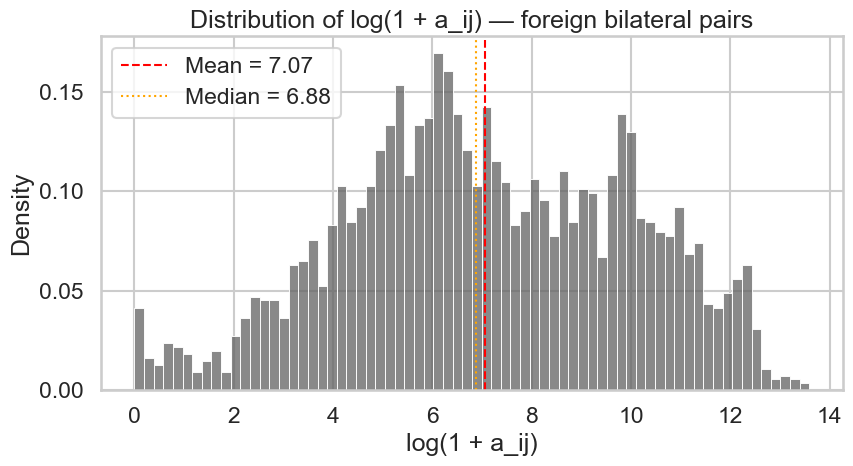

Skewness of log(1+a_ij): -0.095 | Kurtosis: -0.593


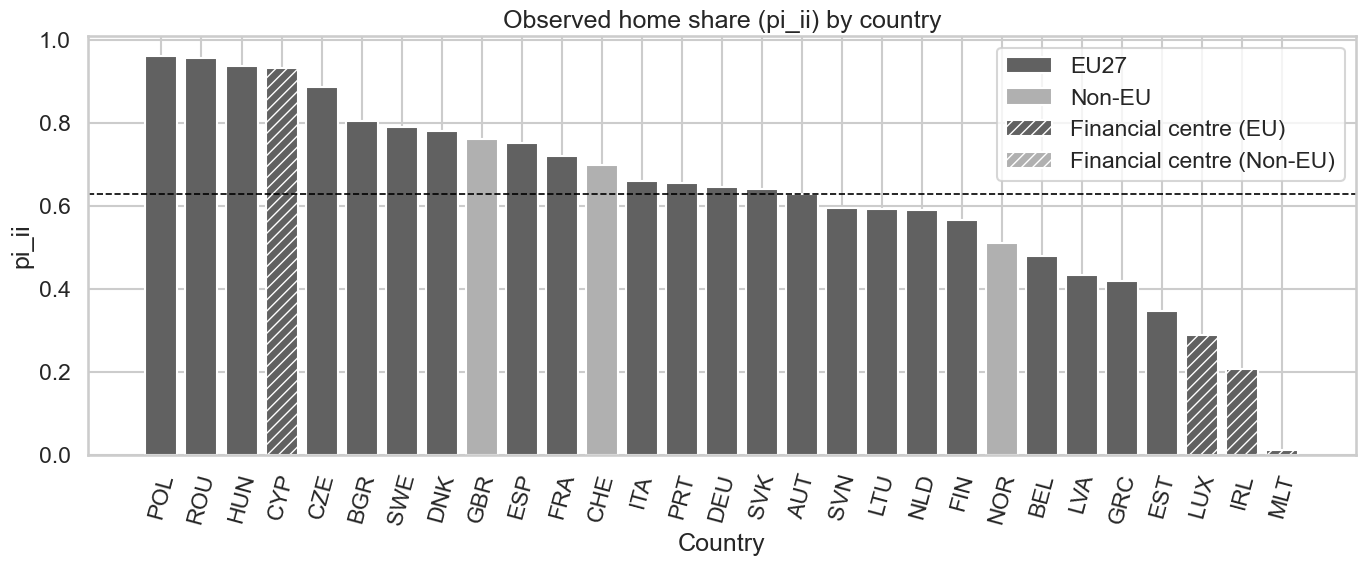

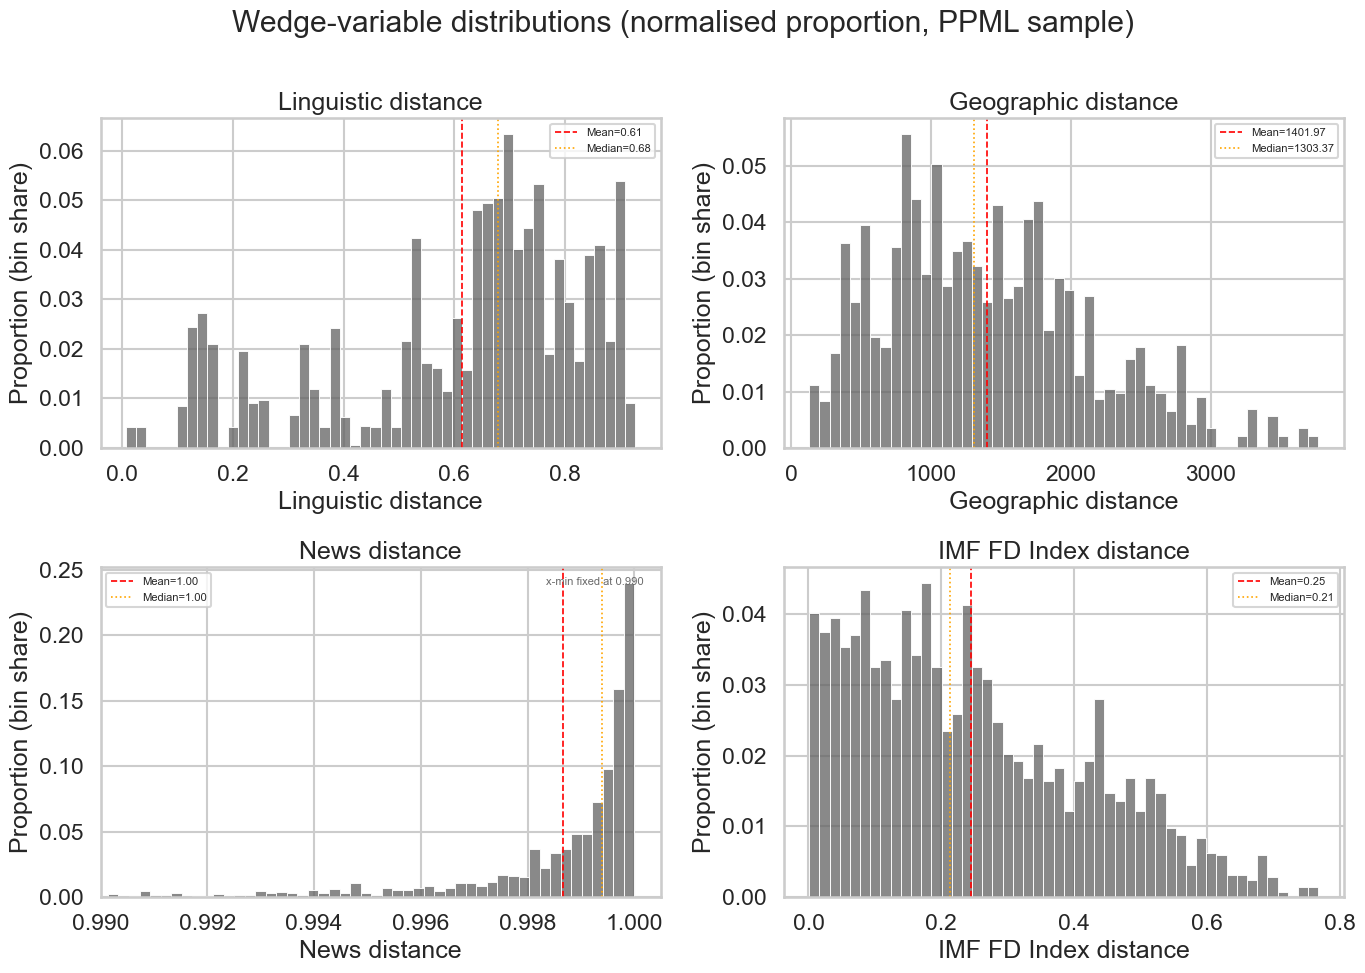

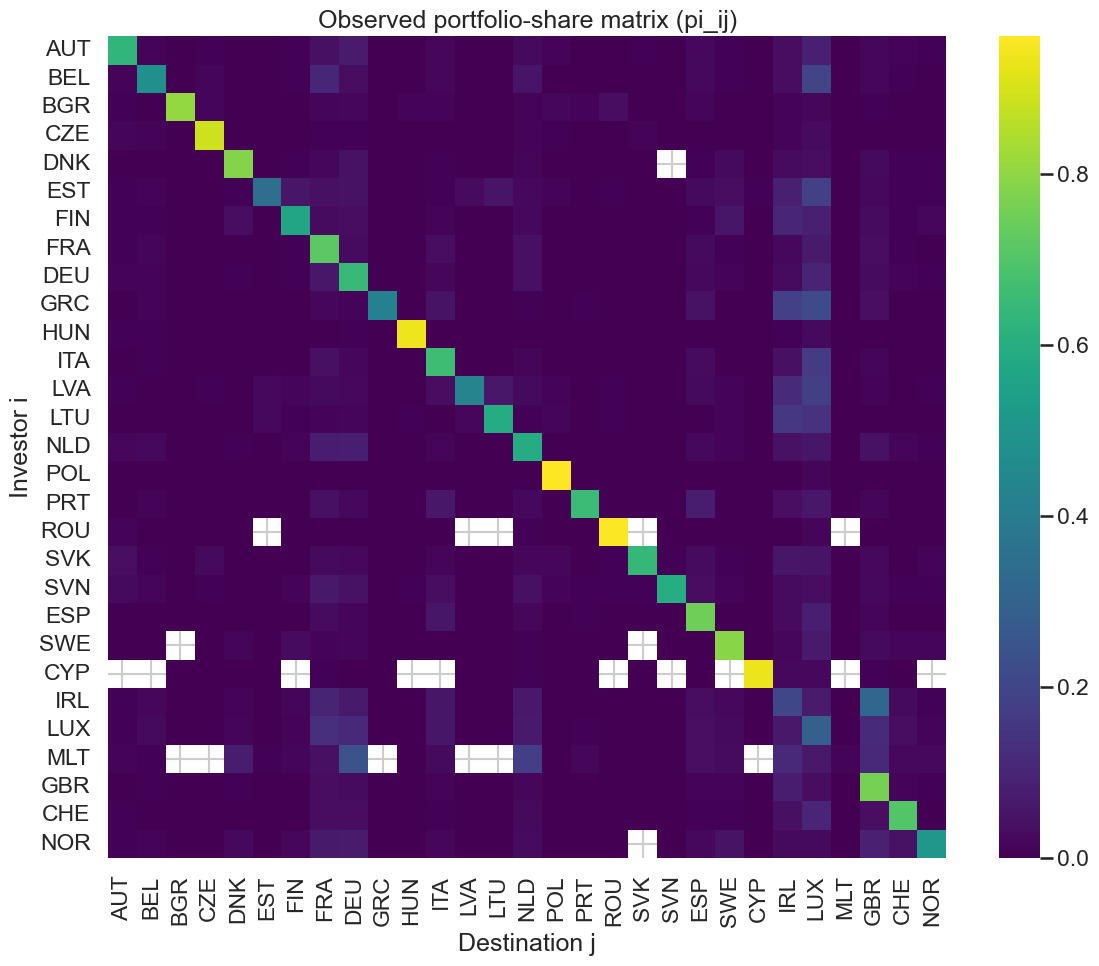

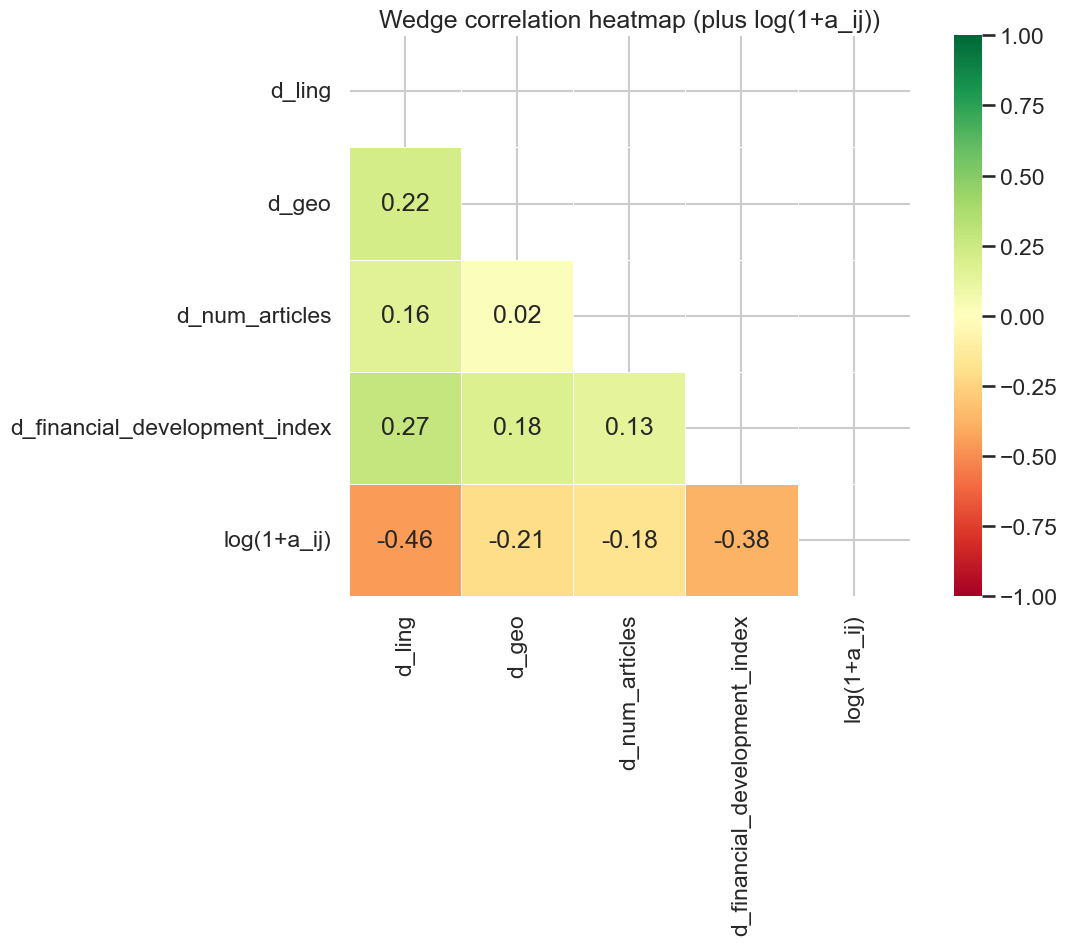

,variable,VIF,interpretation
0,d_ling,9.336,Moderate (5-10)
1,d_geo,4.922,Low (<5)
2,d_num_articles,10.518,High >10
3,d_financial_development_index,3.330,Low (<5)


In [6]:
from matplotlib.patches import Patch

# ── Section 5a: Portfolio holdings distribution (foreign pairs only) ─────────
log_aij = np.log1p(df_ppml['a_ij'])
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(log_aij, bins=70, stat='density', ax=ax, color='#616161')
ax.axvline(log_aij.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean = {log_aij.mean():.2f}')
ax.axvline(log_aij.median(), color='orange', linestyle=':',  linewidth=1.5, label=f'Median = {log_aij.median():.2f}')
ax.set_title('Distribution of log(1 + a_ij) — foreign bilateral pairs')
ax.set_xlabel('log(1 + a_ij)')
ax.set_ylabel('Density')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'data_05a_log_holdings_distribution.png', dpi=220)
plt.show()
print(f'Skewness of log(1+a_ij): {log_aij.skew():.3f} | Kurtosis: {log_aij.kurt():.3f}')

# ── Section 5b: Observed home-share chart (sorted country bars) ──────────────
hs_plot = home_share.dropna().sort_values(ascending=False)

def get_bar_color(c):
    if c not in EU27:
        return '#b0b0b0'
    return '#616161'

bar_colors = [get_bar_color(c) for c in hs_plot.index]
bar_hatches = ['///' if c in FINANCIAL_CENTRES else '' for c in hs_plot.index]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(hs_plot.index, hs_plot.values, color=bar_colors, hatch=bar_hatches, edgecolor='white')
ax.axhline(hs_plot.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean = {hs_plot.mean():.2f}')
ax.set_title('Observed home share (pi_ii) by country')
ax.set_xlabel('Country')
ax.set_ylabel('pi_ii')
ax.tick_params(axis='x', rotation=75)
legend_elements = [
    Patch(facecolor='#616161', label='EU27'),
    Patch(facecolor='#b0b0b0', label='Non-EU'),
    Patch(facecolor='#616161', hatch='///', edgecolor='white', label='Financial centre (EU)'),
    Patch(facecolor='#b0b0b0', hatch='///', edgecolor='white', label='Financial centre (Non-EU)'),
]
ax.legend(handles=legend_elements)
fig.tight_layout()
fig.savefig(OUT_DIR / 'data_05b_home_share_bar.png', dpi=220)
plt.show()

# ── Section 5c: Wedge-variable distributions (normalised bin share) ──────────
wedge_plot_cols = [(c, l) for c, l in [
    ('d_ling', 'Linguistic distance'),
    ('d_geo', 'Geographic distance'),
    ('d_num_articles', 'News distance'),
    ('d_financial_development_index', 'IMF FD Index distance'),
] if c in df_ppml.columns]

if wedge_plot_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (col, lbl) in zip(axes, wedge_plot_cols):
        s_raw = pd.to_numeric(df_ppml[col], errors='coerce').dropna()

        # For news distance, force panel to start at 0.990.
        if col == 'd_num_articles' and len(s_raw) > 0:
            s = s_raw[s_raw >= 0.990]
            if len(s) == 0:
                s = s_raw
            note = 'x-min fixed at 0.990'
        else:
            s = s_raw
            note = ''

        # Use probability (bin share) so y-axis is interpreted as proportion, not count.
        sns.histplot(s, bins=50, stat='probability', ax=ax, color='#616161')
        ax.axvline(s.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean={s.mean():.2f}')
        ax.axvline(s.median(), color='orange', linestyle=':',  linewidth=1.2, label=f'Median={s.median():.2f}')
        ax.set_title(lbl)
        ax.set_xlabel(lbl)
        ax.set_ylabel('Proportion (bin share)')
        if col == 'd_num_articles':
            ax.set_xlim(left=0.990)
        ax.legend(fontsize=8)
        if note:
            ax.text(0.97, 0.97, note, transform=ax.transAxes, ha='right', va='top', fontsize=8, color='dimgray')

    # Hide unused axes if fewer than 4 panels are available
    for ax in axes[len(wedge_plot_cols):]:
        ax.set_visible(False)

    fig.suptitle('Wedge-variable distributions (normalised proportion, PPML sample)', y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.98])  # reserve top space for title
    fig.savefig(OUT_DIR / 'data_05c_wedge_distributions_density.png', dpi=220, bbox_inches='tight')
    plt.show()

# ── Section 5d: Portfolio-share heatmap (pi_ij) ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(Pi_data.reindex(index=SIM_COUNTRIES, columns=SIM_COUNTRIES), cmap='viridis', ax=ax)
ax.set_title('Observed portfolio-share matrix (pi_ij)')
ax.set_xlabel('Destination j')
ax.set_ylabel('Investor i')
fig.tight_layout()
fig.savefig(OUT_DIR / 'data_05d_portfolio_share_heatmap.png', dpi=220)
plt.show()

# ── Section 6: Wedge correlation heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12.6, 9.8))
mask = np.triu(np.ones_like(corr_matrix_table, dtype=bool))
sns.heatmap(corr_matrix_table, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title('Wedge correlation heatmap (plus log(1+a_ij))')
fig.tight_layout()
fig.savefig(OUT_DIR / 'data_06a_wedge_correlation_heatmap.png', dpi=220)
plt.show()

# Optional: VIF diagnostics for wedge variables
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_cols = [c for c in ['d_ling', 'd_geo', 'd_num_articles', 'd_financial_development_index'] if c in df_ppml.columns]
    vif_df = df_ppml[vif_cols].dropna()
    if len(vif_df) > 10 and len(vif_cols) >= 2:
        vif_vals = [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_cols))]
        vif_table = pd.DataFrame({
            'variable': vif_cols,
            'VIF': [round(v, 3) for v in vif_vals],
            'interpretation': ['Low (<5)' if v < 5 else ('Moderate (5-10)' if v < 10 else 'High >10') for v in vif_vals],
        })
        display(vif_table)
except ImportError:
    print('statsmodels not available — skipping VIF table')

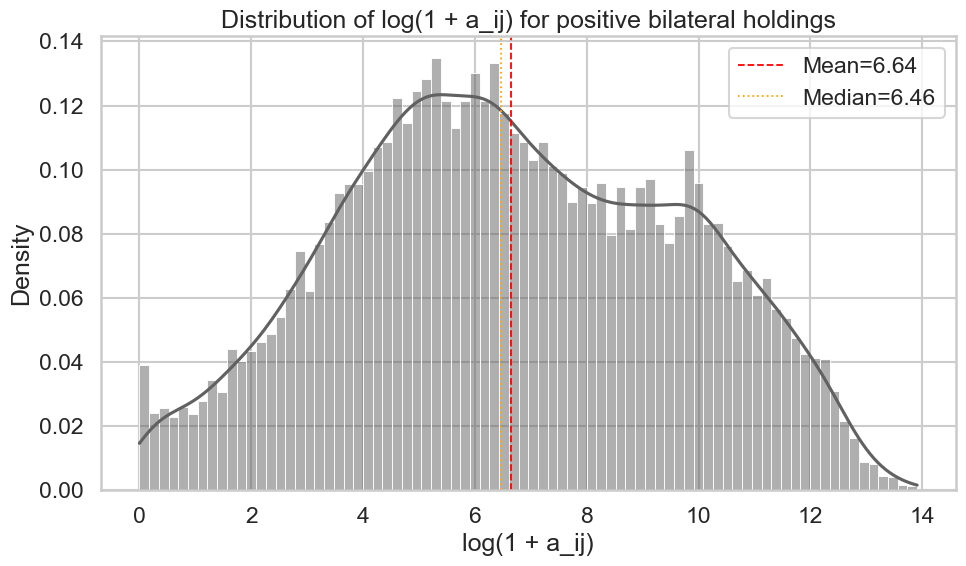

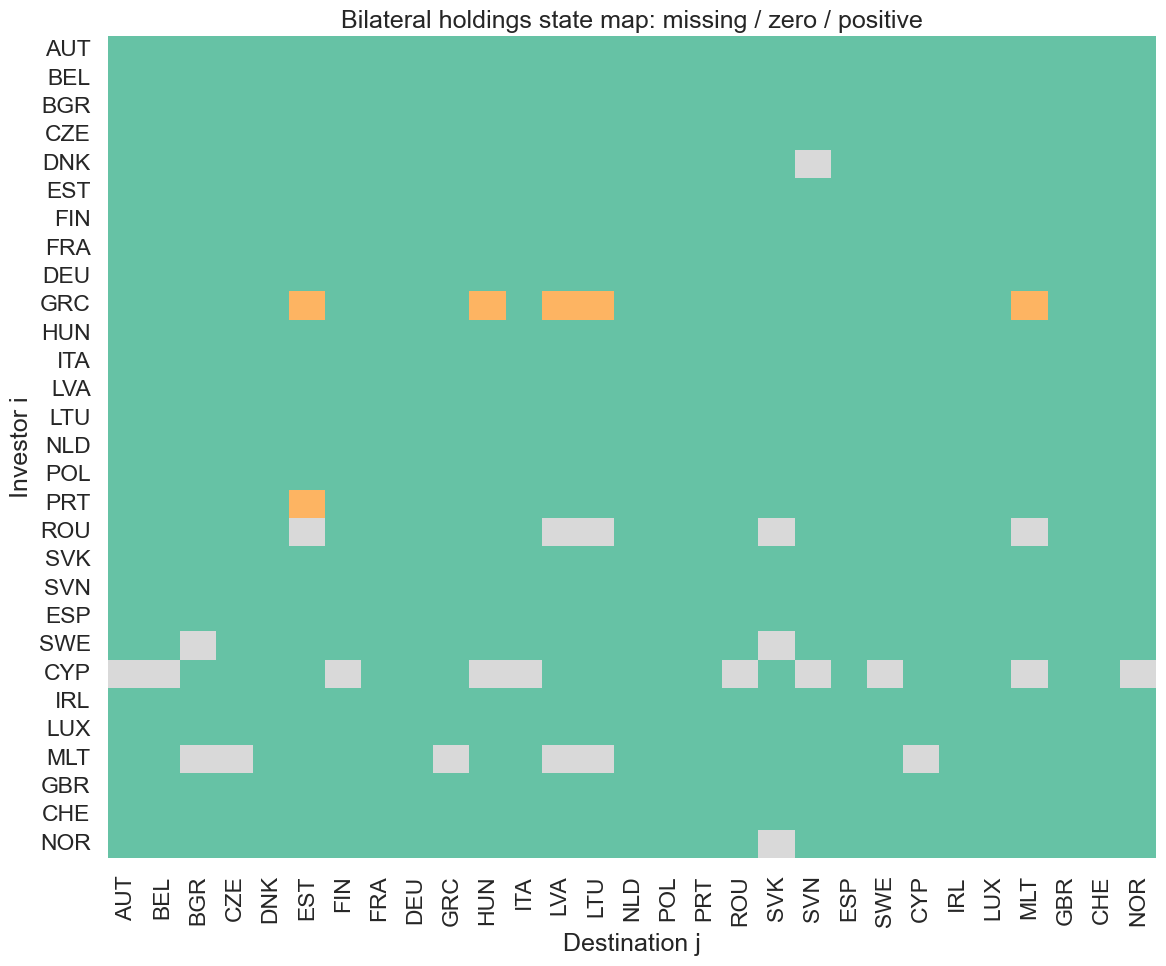

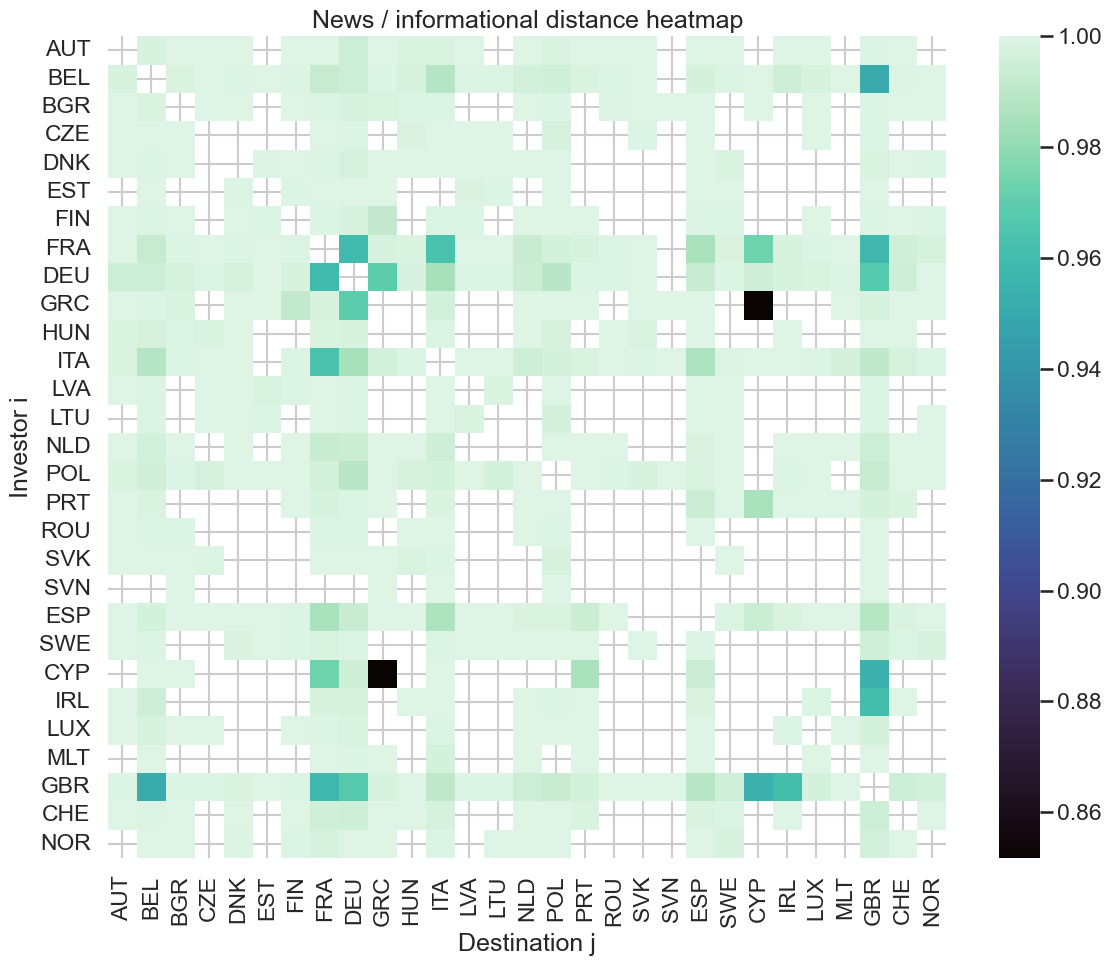

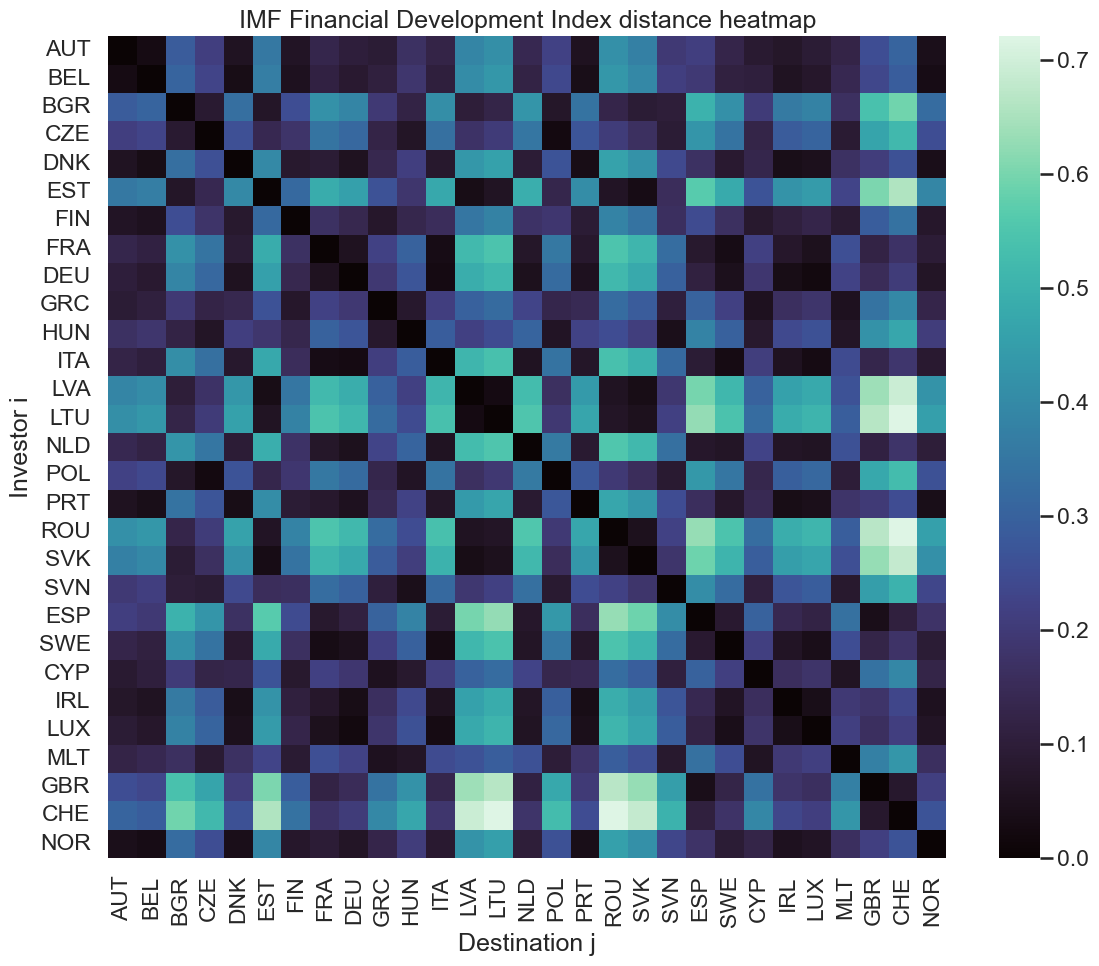

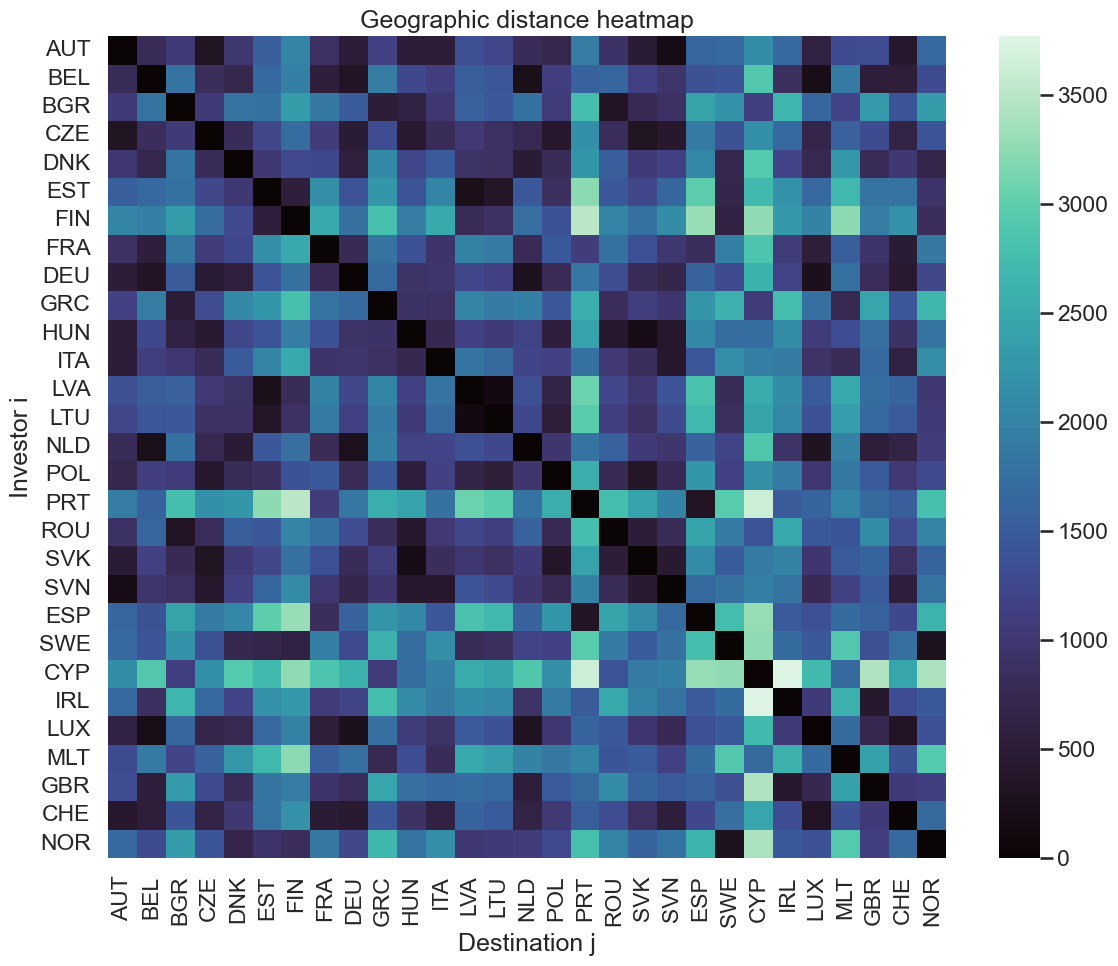

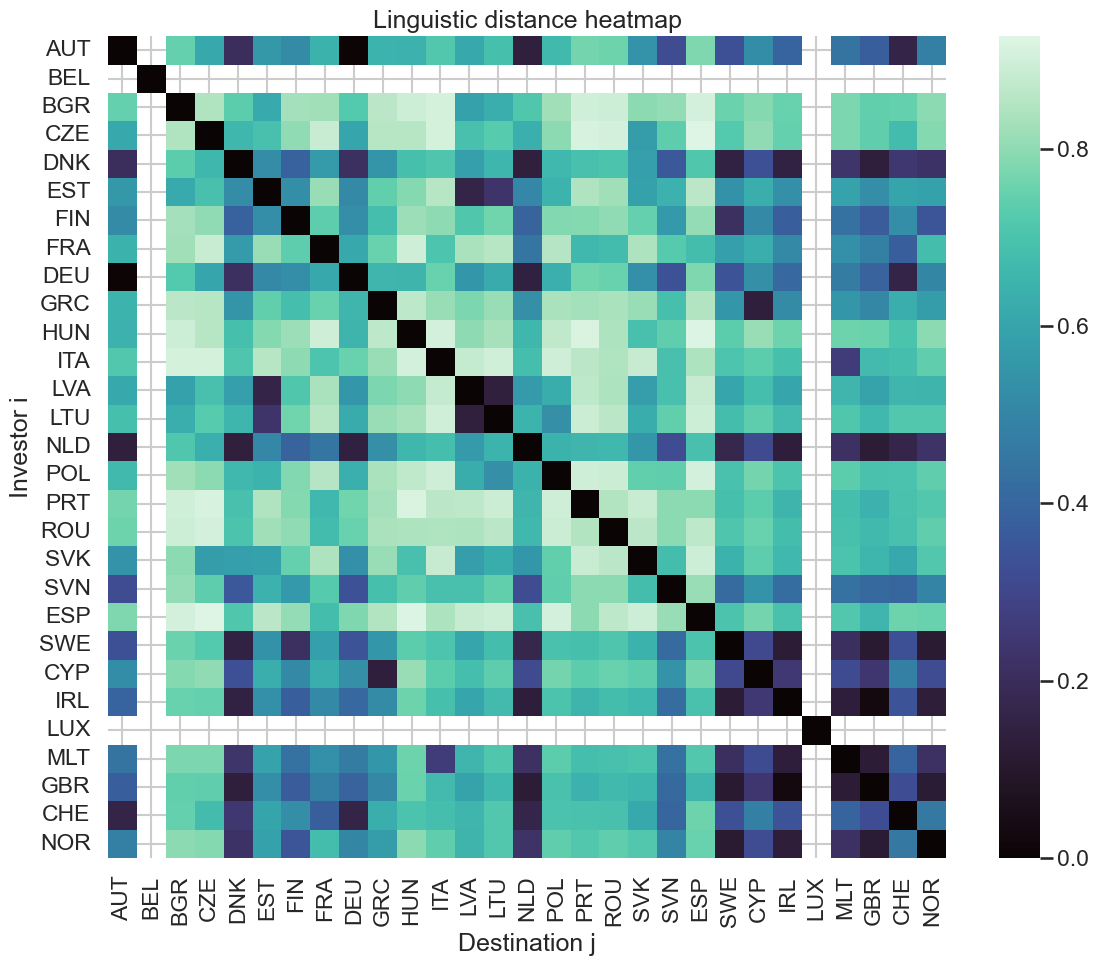

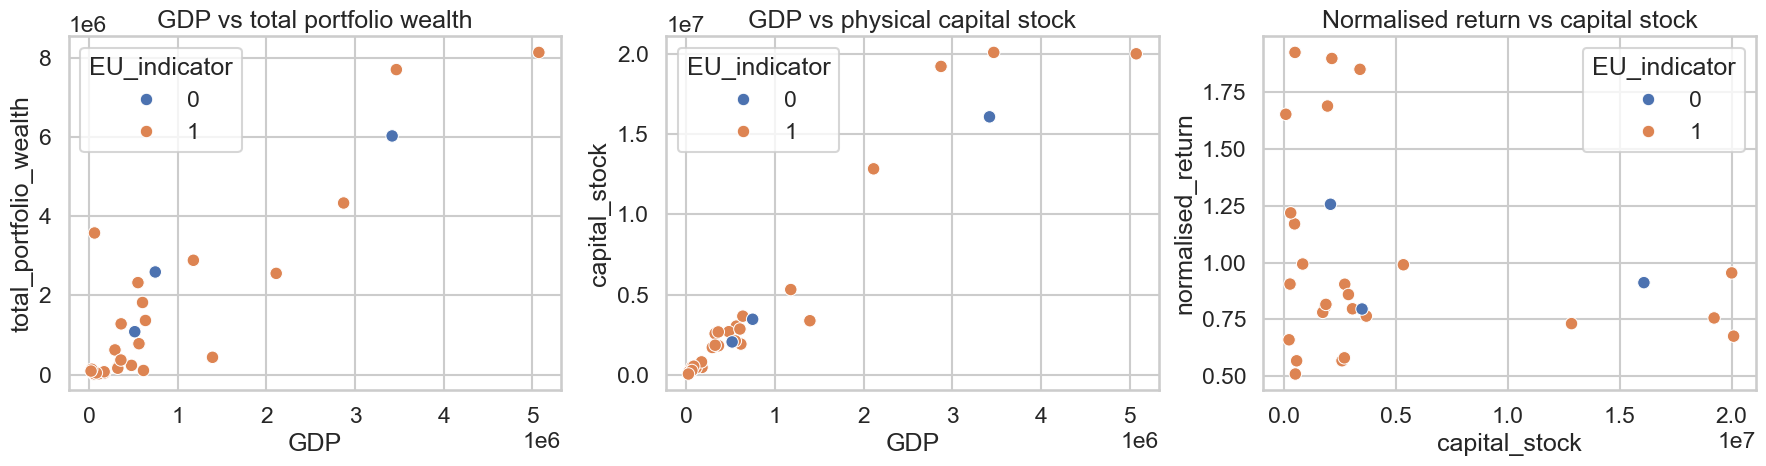

Saved figures to: /Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/imgs


In [7]:
from matplotlib.colors import ListedColormap

# A) Raw bilateral holdings distribution (distributional histplot)
raw_pos = df_country.loc[df_country['a_ij'] > 0, 'a_ij'].dropna()
log_raw_pos = np.log1p(raw_pos)
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(log_raw_pos, bins=80, stat='density', kde=True, ax=ax, color="#616161")
ax.axvline(log_raw_pos.mean(), color='red', linestyle='--', linewidth=1.3, label=f"Mean={log_raw_pos.mean():.2f}")
ax.axvline(log_raw_pos.median(), color='orange', linestyle=':', linewidth=1.3, label=f"Median={log_raw_pos.median():.2f}")
ax.set_title('Distribution of log(1 + a_ij) for positive bilateral holdings')
ax.set_xlabel('log(1 + a_ij)')
ax.set_ylabel('Density')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'data_A1_raw_holdings_distribution_log1p.png', dpi=220)
plt.show()

# B) Bilateral holdings missingness/state heatmap
state = A.copy()
state = state.where(~state.isna(), -1)
state = state.where(~(state == 0), 0)
state = state.where(~(state > 0), 1)
# map: -1 missing, 0 zero, 1 positive
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(state, cmap=ListedColormap(['#d9d9d9', '#fdb462', '#66c2a5']), cbar=False, ax=ax)
ax.set_title('Bilateral holdings state map: missing / zero / positive')
ax.set_xlabel('Destination j')
ax.set_ylabel('Investor i')
fig.tight_layout()
fig.savefig(OUT_DIR / 'data_A2_bilateral_state_heatmap.png', dpi=220)
plt.show()

# C) News, IMF Financial Development Index-distance, geographic, linguistic heatmaps
friction_heatmaps = [
    ('d_num_articles', 'data_A3_news_distance_heatmap.png', 'News / informational distance heatmap'),
    ('d_financial_development_index', 'data_A4_imf_financial_development_index_distance_heatmap.png', 'IMF Financial Development Index distance heatmap'),
    ('d_geo', 'data_A5_geographic_distance_heatmap.png', 'Geographic distance heatmap'),
    ('d_ling', 'data_A6_linguistic_distance_heatmap.png', 'Linguistic distance heatmap'),
]

for col, fname, ttl in friction_heatmaps:
    if col not in base.columns and col not in df_country.columns:
        print(f'Skipping {ttl} — column {col} not in data')
        continue

    # For IMF financial development distance, use all years (pair mean)
    # to avoid empty base-year heatmaps when the base year has sparse coverage.
    src = df_country if col == 'd_financial_development_index' else base

    if col not in src.columns:
        print(f'Skipping {ttl} — column {col} not in selected source data')
        continue

    M = src.pivot_table(index='iso3_i', columns='iso3_j', values=col, aggfunc='mean').reindex(index=SIM_COUNTRIES, columns=SIM_COUNTRIES)

    if M.isna().all().all():
        print(f'Skipping {ttl} — all values are missing after construction')
        continue

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(M, cmap='mako', ax=ax)
    ax.set_title(ttl)
    ax.set_xlabel('Destination j')
    ax.set_ylabel('Investor i')
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=220)
    plt.show()

# D) Foreign capital intensity bar chart
f_plot = country_baseline_table[['country', 'foreign_capital_intensity']].dropna().sort_values('foreign_capital_intensity', ascending=False)
if len(f_plot) > 0:
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.bar(f_plot['country'], f_plot['foreign_capital_intensity'], color='#4c78a8')
    ax.set_title('Baseline foreign capital intensity by country')
    ax.set_xlabel('Country')
    ax.set_ylabel('f_i = k_i^foreign / k_i^PWT')
    ax.tick_params(axis='x', rotation=75)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'data_A7_foreign_capital_intensity_bar.png', dpi=220)
    plt.show()

# E) Macro scatterplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tmp = country_baseline_table.copy()
sns.scatterplot(data=tmp, x='GDP', y='total_portfolio_wealth', hue='EU_indicator', ax=axes[0])
axes[0].set_title('GDP vs total portfolio wealth')
sns.scatterplot(data=tmp, x='GDP', y='capital_stock', hue='EU_indicator', ax=axes[1])
axes[1].set_title('GDP vs physical capital stock')
sns.scatterplot(data=tmp, x='capital_stock', y='normalised_return', hue='EU_indicator', ax=axes[2])
axes[2].set_title('Normalised return vs capital stock')
fig.tight_layout()
fig.savefig(OUT_DIR / 'data_A8_macro_scatterplots.png', dpi=220)
plt.show()

print('Saved figures to:', OUT_DIR.resolve())

## Appendix figures

Appendix figures are generated in the previous plotting cell and saved to imgs/ with data_ prefix.
This avoids duplicate code and overwriting from repeated runs.

## Suggested thesis placement

**Main text:**
1. Data sources and variable mapping table
2. Sample construction table
3. Main descriptive statistics table
4. Missingness and treatment table
5. Home-bias table or country bar chart
6. Distribution of log(1+a_ij)
7. Four-panel friction distributions
8. Correlation heatmap
9. Observed portfolio-share heatmap

**Appendix:**
- Raw holdings distribution
- Bilateral state/missingness heatmap
- News / IMF Financial Development Index / geographic / linguistic heatmaps
- Foreign capital intensity bar chart
- Macro scatterplots